<div style="padding:34px 38px;border-radius:22px;background:linear-gradient(120deg,#0B132B 0%,#1C2541 58%,#0F766E 100%);color:white;box-shadow:0 14px 35px rgba(7,26,43,.18)">
  <div style="font-size:13px;font-weight:800;letter-spacing:1.8px;text-transform:uppercase;color:#99F6E4">Customer Analytics - Machine Learning Portfolio Project</div>
  <div style="font-size:38px;font-weight:900;line-height:1.08;margin-top:10px">Bank Customer Churn Prediction</div>
  <div style="font-size:18px;line-height:1.55;margin-top:12px;color:#E0F2FE">A leakage-safe, decision-focused machine learning study</div>
  <div style="display:flex;flex-wrap:wrap;gap:9px;margin-top:20px">
    <span style="padding:7px 12px;border-radius:999px;background:#14B8A6;color:#071A2B;font-weight:700">10,000 customers</span>
    <span style="padding:7px 12px;border-radius:999px;background:#38BDF8;color:#071A2B;font-weight:700">3 model families</span>
    <span style="padding:7px 12px;border-radius:999px;background:#FBBF24;color:#071A2B;font-weight:700">5-fold CV</span>
    <span style="padding:7px 12px;border-radius:999px;background:#FB7185;color:#071A2B;font-weight:700">Recall-aware decision rule</span>
  </div>
</div>

<div style="margin:8px 0 0;color:#071A2B;font-size:15px;line-height:1.65">
  <div><strong>Project type:</strong> Personal machine learning portfolio project.</div>
  <div><strong>Objective:</strong> Predict churn reliably, explain the drivers, and translate model performance into an operational retention decision.</div>
</div>

## Project map and evaluation philosophy

This notebook covers each project section explicitly (`A1` through `D11`) and adds the controls expected in a strong real-world project:

1. **Data integrity checks** before analysis.
2. **Identifier exclusion:** `customer_id` is an account number, not a behavioral predictor.
3. **Leakage-safe pipelines:** imputing, scaling, and encoding are fitted inside each training fold.
4. **Stratified 80/20 holdout:** the test set remains untouched during tuning and model selection.
5. **Five-fold cross-validation:** models are selected using **average precision (PR-AUC)**, which is informative for the 20% churn class.
6. **Required metrics plus context:** accuracy, precision, recall, and F1 are reported alongside PR-AUC, ROC-AUC, curves, and confusion matrices.
7. **Decision threshold chosen from out-of-fold training predictions**, never from the test labels.
8. **Held-out permutation importance** and descriptive segment rates for defensible interpretation.

> A model predicts association, not causation. Recommendations below require validation through controlled retention experiments.

## 0. Environment and reproducibility

The first cell installs only packages that are missing. This keeps the notebook runnable in Google Colab while avoiding unnecessary reinstalls in a prepared environment.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas>=2.0",
    "numpy": "numpy>=1.24",
    "sklearn": "scikit-learn>=1.4",
    "matplotlib": "matplotlib>=3.7",
    "seaborn": "seaborn>=0.13",
    "xgboost": "xgboost>=2.0",
}
missing = [package for module, package in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are available.")

All required packages are available.


In [2]:
%matplotlib inline

import platform
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from IPython.display import HTML, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
SEARCH_JOBS = -1 if IN_COLAB else 1
NOTEBOOK_STARTED = time.perf_counter()

COLORS = {
    "navy": "#0B132B",
    "slate": "#334155",
    "teal": "#14B8A6",
    "cyan": "#38BDF8",
    "amber": "#FBBF24",
    "coral": "#FB7185",
    "purple": "#8B5CF6",
    "green": "#22C55E",
    "light": "#E2E8F0",
}
MODEL_COLORS = {
    "Naive baseline": COLORS["slate"],
    "Logistic Regression": COLORS["cyan"],
    "Random Forest": COLORS["teal"],
    "XGBoost": COLORS["coral"],
}

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.figsize": (10, 5.6),
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.edgecolor": "#CBD5E1",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#E2E8F0",
    "grid.alpha": 0.75,
    "legend.frameon": False,
})

def percent_labels(ax, values, decimals=1, pad=0.01):
    for patch, value in zip(ax.patches, values):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + pad,
            f"{value:.{decimals}%}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=COLORS["navy"],
        )


def project_table(styler, caption, note=None):
    """Apply one accessible, consistent caption treatment to project tables."""
    caption_html = f"<span class='project-table-title'>{caption}</span>"
    if note:
        caption_html += (
            f"<span class='project-table-note'>{note}</span>"
        )
    return (
        styler
        .set_caption(caption_html)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "center"),
                    ("color", COLORS["navy"]),
                    ("padding", "0 8px 12px"),
                    ("line-height", "1.35"),
                ],
            },
            {
                "selector": "caption .project-table-title",
                "props": [
                    ("display", "block"),
                    ("font-size", "15px"),
                    ("font-weight", "800"),
                ],
            },
            {
                "selector": "caption .project-table-note",
                "props": [
                    ("display", "block"),
                    ("font-size", "12px"),
                    ("font-weight", "400"),
                    ("margin-top", "4px"),
                    ("color", COLORS["slate"]),
                ],
            },
            {
                "selector": "th.col_heading",
                "props": [
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                ],
            },
        ], overwrite=False)
    )


def vertical_space(pixels=32):
    """Create a deliberate visual break between separate notebook outputs."""
    display(HTML(
        f"<div aria-hidden='true' style='height:{max(0, int(pixels))}px'></div>"
    ))


def centered_result(label, value, *, bold_value=False):
    value_weight = "700" if bold_value else "400"
    display(HTML(
        f"""
        <div style='margin:10px 0 0;text-align:center;font-size:13px;color:{COLORS['slate']}'>
          <strong style='color:{COLORS['navy']}'>{label}</strong>
          <span style='font-weight:{value_weight}'>{value}</span>
        </div>
        """
    ))

print(f"Python {platform.python_version()} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | XGBoost {xgboost.__version__}")
print(f"Random seed: {RANDOM_STATE} | Search workers: {SEARCH_JOBS}")

Python 3.12.13 | pandas 3.0.5 | scikit-learn 1.9.0 | XGBoost 3.4.0
Random seed: 42 | Search workers: 1


### Data loading and integrity gate

The loader accepts both the supplied filename and the original notebook's `bank_data.csv` alias. In Colab, it requests an upload only when neither file is present.

In [3]:
CANDIDATE_FILENAMES = [
    "Bank Customer Churn Prediction.csv",
    "bank_data.csv",
]
SEARCH_DIRECTORIES = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive")]

data_path = next(
    (
        directory / filename
        for directory in SEARCH_DIRECTORIES
        for filename in CANDIDATE_FILENAMES
        if (directory / filename).is_file()
    ),
    None,
)

if data_path is None and IN_COLAB:
    from google.colab import files
    print("Dataset not found. Please upload the customer churn CSV.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No CSV was uploaded.")
    uploaded_csvs = [Path(name) for name in uploaded if name.lower().endswith(".csv")]
    if not uploaded_csvs:
        raise FileNotFoundError("The uploaded files did not include a CSV.")
    data_path = uploaded_csvs[0]

if data_path is None:
    raise FileNotFoundError(
        "Place 'Bank Customer Churn Prediction.csv' beside this notebook, "
        "or rename it to 'bank_data.csv'."
    )

df = pd.read_csv(data_path)
df.columns = df.columns.str.strip().str.lower()

EXPECTED_COLUMNS = [
    "customer_id", "credit_score", "country", "gender", "age", "tenure",
    "balance", "products_number", "credit_card", "active_member",
    "estimated_salary", "churn",
]
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
unexpected_columns = sorted(set(df.columns) - set(EXPECTED_COLUMNS))

assert not missing_columns, f"Missing expected columns: {missing_columns}"
assert df.shape == (10_000, 12), f"Unexpected shape: {df.shape}"
assert set(df["churn"].dropna().unique()) == {0, 1}, "churn must contain only 0 and 1"
assert df["customer_id"].is_unique, "customer_id should uniquely identify each row"

quality_summary = pd.DataFrame({
    "Check": ["Rows", "Columns", "Missing cells", "Duplicate rows", "Unique customer IDs"],
    "Result": [
        f"{len(df):,}",
        f"{df.shape[1]}",
        f"{int(df.isna().sum().sum()):,}",
        f"{int(df.duplicated().sum()):,}",
        f"{df['customer_id'].nunique():,}",
    ],
    "Status": ["PASS"] * 5,
})

print(f"Loaded: {data_path.resolve()}")
print(f"Unexpected columns: {unexpected_columns or 'None'}")

vertical_space(24)
display(
    project_table(
        quality_summary.style
        .hide(axis="index")
        .set_properties(**{"text-align": "left"})
        .set_table_styles([
            {"selector": "th", "props": [("background", COLORS["navy"]), ("color", "white"), ("font-weight", "700")]},
            {"selector": "td", "props": [("padding", "8px 12px")]},
        ])
        .map(lambda value: "color:#15803D;font-weight:700" if value == "PASS" else ""),
        "Data quality checks",
    )
)

vertical_space(30)
display(project_table(df.head().style, "Sample customer records"))

Loaded: C:\Users\Sajeev\Documents\Codex\2026-08-13\ok\outputs\Bank Customer Churn Prediction.csv
Unexpected columns: None


Check,Result,Status
Rows,"10,000",PASS
Columns,12,PASS
Missing cells,0,PASS
Duplicate rows,0,PASS
Unique customer IDs,"10,000",PASS


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.000000,1,1,1,101348.880000,1
1,15647311,608,Spain,Female,41,1,83807.860000,1,0,1,112542.580000,0
2,15619304,502,France,Female,42,8,159660.800000,3,1,0,113931.570000,1
3,15701354,699,France,Female,39,1,0.000000,2,0,0,93826.630000,0
4,15737888,850,Spain,Female,43,2,125510.820000,1,1,1,79084.100000,0


# Part A - Data Understanding

## A1 - Overall churn rate

The overall churn rate is calculated as the number of customers with `churn = 1` divided by all customers.

Outcome,Customers,Share
Stayed (0),"7,963",79.63%
Churned (1),"2,037",20.37%


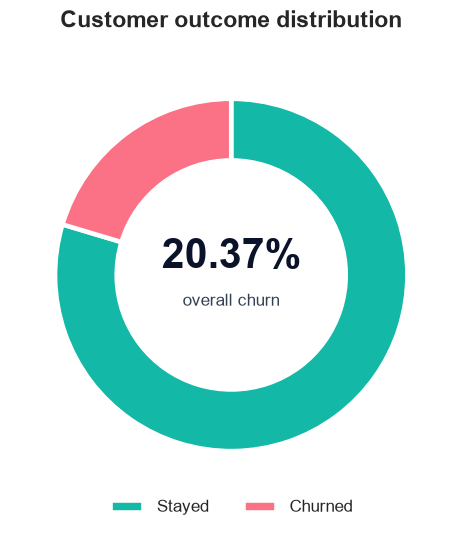

In [4]:
churn_counts = df["churn"].value_counts().sort_index()
churn_rate = df["churn"].mean()
target_summary = pd.DataFrame({
    "Outcome": ["Stayed (0)", "Churned (1)"],
    "Customers": [churn_counts[0], churn_counts[1]],
    "Share": [churn_counts[0] / len(df), churn_counts[1] / len(df)],
})

display(
    project_table(
        target_summary.style
        .hide(axis="index")
        .format({"Customers": "{:,.0f}", "Share": "{:.2%}"})
        .set_table_styles([{"selector": "th", "props": [("background", COLORS["navy"]), ("color", "white")]}]),
        "Customer outcome summary",
    )
)

vertical_space(34)
fig, ax = plt.subplots(figsize=(7.6, 5.2))
wedges, _ = ax.pie(
    target_summary["Customers"],
    startangle=90,
    counterclock=False,
    colors=[COLORS["teal"], COLORS["coral"]],
    wedgeprops={"width": 0.35, "edgecolor": "white", "linewidth": 3},
)
ax.text(0, 0.10, f"{churn_rate:.2%}", ha="center", va="center", fontsize=27,
        fontweight="bold", color=COLORS["navy"])
ax.text(0, -0.15, "overall churn", ha="center", va="center", fontsize=11, color=COLORS["slate"])
ax.legend(wedges, ["Stayed", "Churned"], loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=2)
ax.set_title("Customer outcome distribution", pad=18)
plt.show()

**A1.** The dataset contains **2,037 churned customers out of 10,000**, so the overall churn rate is **20.37%**. A majority-class prediction would therefore appear to achieve 79.63% accuracy while identifying no churners; this is why recall, F1, and PR-AUC matter.

## A2 - Distribution of customers by country

Country,Customers,Share
France,"5,014",50.14%
Germany,"2,509",25.09%
Spain,"2,477",24.77%


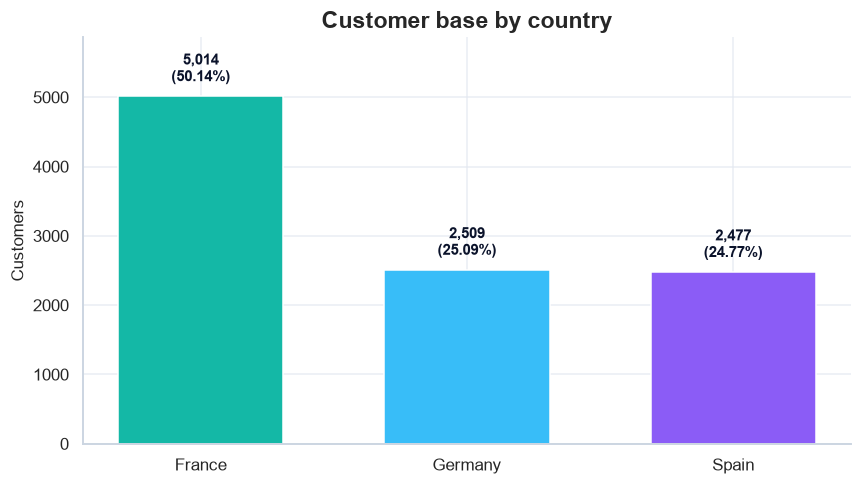

In [5]:
country_summary = (
    df["country"]
    .value_counts()
    .rename_axis("Country")
    .reset_index(name="Customers")
)
country_summary["Share"] = country_summary["Customers"] / len(df)

display(
    project_table(
        country_summary.style
        .hide(axis="index")
        .format({"Customers": "{:,.0f}", "Share": "{:.2%}"})
        .background_gradient(subset=["Share"], cmap="GnBu"),
        "Customer distribution by country",
    )
)

vertical_space(34)
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [COLORS["teal"], COLORS["cyan"], COLORS["purple"]]
bars = ax.bar(country_summary["Country"], country_summary["Customers"], color=colors, width=0.62)
ax.set_title("Customer base by country")
ax.set_ylabel("Customers")
ax.set_ylim(0, country_summary["Customers"].max() * 1.17)
ax.bar_label(
    bars,
    labels=[f"{count:,}{chr(10)}({share:.2%})" for count, share in zip(country_summary["Customers"], country_summary["Share"])],
    padding=7,
    fontsize=10,
    fontweight="bold",
    color=COLORS["navy"],
)
plt.show()

**A2.** France contributes **5,014 customers (50.14%)**, Germany **2,509 (25.09%)**, and Spain **2,477 (24.77%)**. Country-level model performance should therefore be reviewed because Germany and Spain have roughly half France's sample size.

## A3 - Average credit score by churn outcome

Outcome,Customers,Mean,CI low,CI high
Stayed,"7,963",651.85,649.75,653.95
Churned,"2,037",645.35,640.99,649.71


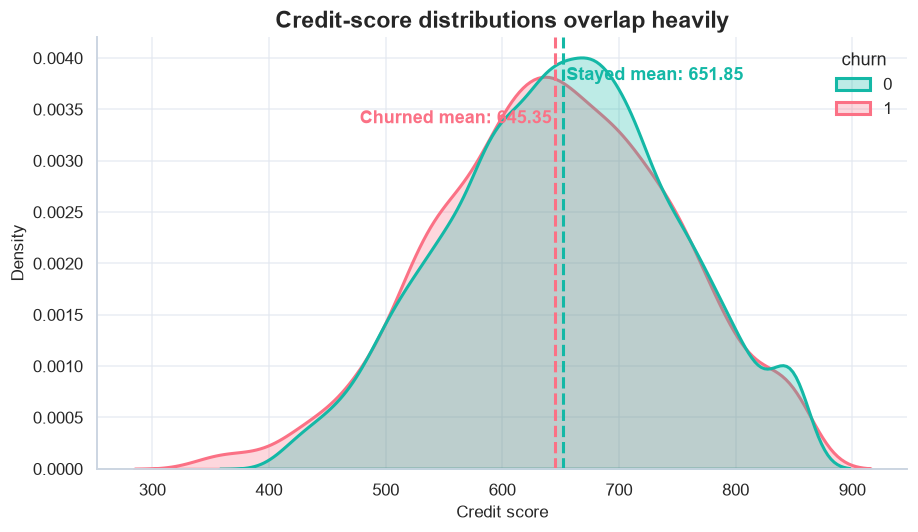

In [6]:
credit_summary = (
    df.groupby("churn")["credit_score"]
    .agg(Customers="size", Mean="mean", Std="std", SEM="sem")
    .rename(index={0: "Stayed", 1: "Churned"})
)
credit_summary["CI low"] = credit_summary["Mean"] - 1.96 * credit_summary["SEM"]
credit_summary["CI high"] = credit_summary["Mean"] + 1.96 * credit_summary["SEM"]

stayed_scores = df.loc[df["churn"].eq(0), "credit_score"]
churned_scores = df.loc[df["churn"].eq(1), "credit_score"]
pooled_sd = np.sqrt(
    ((len(stayed_scores) - 1) * stayed_scores.var(ddof=1)
     + (len(churned_scores) - 1) * churned_scores.var(ddof=1))
    / (len(stayed_scores) + len(churned_scores) - 2)
)
mean_difference = churned_scores.mean() - stayed_scores.mean()
cohens_d = mean_difference / pooled_sd

credit_summary_display = (
    credit_summary[["Customers", "Mean", "CI low", "CI high"]]
    .rename_axis("Outcome")
    .reset_index()
)
display(
    project_table(
        credit_summary_display.style
        .hide(axis="index")
        .format({"Customers": "{:,.0f}", "Mean": "{:.2f}", "CI low": "{:.2f}", "CI high": "{:.2f}"}),
        "Credit-score summary by customer outcome",
    )
)
centered_result(
    "Key comparison:",
    f"Churned - stayed mean difference = {mean_difference:.2f} credit-score units | Cohen's d = {cohens_d:.3f}",
)

vertical_space(34)
fig, ax = plt.subplots(figsize=(9.5, 5.1))
sns.kdeplot(data=df, x="credit_score", hue="churn", common_norm=False, fill=True,
            alpha=0.28, linewidth=2, palette={0: COLORS["teal"], 1: COLORS["coral"]}, ax=ax)
ax.axvline(stayed_scores.mean(), color=COLORS["teal"], linestyle="--", linewidth=2)
ax.axvline(churned_scores.mean(), color=COLORS["coral"], linestyle="--", linewidth=2)
ax.set_title("Credit-score distributions overlap heavily")
ax.set_xlabel("Credit score")
ax.set_ylabel("Density")
ax.text(stayed_scores.mean() + 3, ax.get_ylim()[1] * 0.90, f"Stayed mean: {stayed_scores.mean():.2f}", color=COLORS["teal"], fontweight="bold")
ax.text(churned_scores.mean() - 3, ax.get_ylim()[1] * 0.80, f"Churned mean: {churned_scores.mean():.2f}", color=COLORS["coral"], fontweight="bold", ha="right")
plt.show()

**A3.** Non-churned customers average **651.85**, versus **645.35** for churned customers: churned customers are lower by **6.50 credit-score units**. The standardized difference is only about **-0.067**, and the distributions overlap strongly, so credit score alone has little practical separation power.

# Part B - Model Development

## B4 - Preprocessing strategy

The split is performed **before preprocessing**. Every transformation lives inside a scikit-learn `Pipeline`, so medians, modes, scaling parameters, and one-hot categories are learned from the applicable training fold only.

In [7]:
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "estimated_salary",
]
binary_features = ["credit_card", "active_member"]
categorical_features = ["country", "gender"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", "passthrough", binary_features),
    ("categorical", categorical_pipeline, categorical_features),
], remainder="drop")

split_summary = pd.DataFrame({
    "Partition": ["Training", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Churners": [int(y_train.sum()), int(y_test.sum())],
    "Churn rate": [y_train.mean(), y_test.mean()],
})
display(
    project_table(
        split_summary.style
        .hide(axis="index")
        .format({"Rows": "{:,.0f}", "Churners": "{:,.0f}", "Churn rate": "{:.2%}"}),
        "Training and test partition summary",
    )
)

Partition,Rows,Churners,Churn rate
Training,"8,000","1,630",20.38%
Test,"2,000",407,20.35%


**B4.**

- `customer_id` is excluded because it is a unique account identifier with no defensible future predictive meaning.
- Continuous/count features receive median imputation and standardization. Scaling is essential for Logistic Regression and harmless within a shared comparison pipeline.
- Binary 0/1 indicators pass through unchanged.
- `country` and `gender` receive mode imputation and one-hot encoding with unknown-category handling.
- Class weighting is tuned **inside cross-validation** rather than oversampling before the split, preventing synthetic-data leakage.
- The stratified test set contains 2,000 customers and preserves the 20.35% churn prevalence.

## B5 - Three classification models

Three complementary model families are compared:

1. **Logistic Regression** - transparent linear baseline.
2. **Random Forest** - bagged nonlinear trees, robust to interactions.
3. **XGBoost** - regularized gradient boosting, strong on structured tabular data.

Hyperparameters are chosen only from the training set using five-fold stratified CV. **Average precision (PR-AUC)** is the primary selection score because churn is the minority outcome; required threshold metrics are evaluated afterward.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
}

searches = {
    "Logistic Regression": GridSearchCV(
        Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        param_grid={
            "model__C": [0.03, 0.1, 0.3, 1.0, 3.0],
            "model__class_weight": [None, "balanced"],
        },
        scoring=scoring,
        refit="average_precision",
        cv=cv,
        n_jobs=SEARCH_JOBS,
        error_score="raise",
    ),
    "Random Forest": RandomizedSearchCV(
        Pipeline([
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        param_distributions={
            "model__n_estimators": [300, 500, 700],
            "model__max_depth": [8, 12, 16, None],
            "model__min_samples_split": [2, 8, 16],
            "model__min_samples_leaf": [1, 3, 6],
            "model__max_features": ["sqrt", 0.7],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        },
        n_iter=12,
        scoring=scoring,
        refit="average_precision",
        cv=cv,
        n_jobs=SEARCH_JOBS,
        random_state=RANDOM_STATE,
        error_score="raise",
    ),
    "XGBoost": RandomizedSearchCV(
        Pipeline([
            ("preprocess", preprocessor),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ]),
        param_distributions={
            "model__n_estimators": [250, 400, 600],
            "model__max_depth": [2, 3, 4, 5],
            "model__learning_rate": [0.03, 0.05, 0.08],
            "model__min_child_weight": [1, 3, 6, 10],
            "model__subsample": [0.75, 0.9, 1.0],
            "model__colsample_bytree": [0.75, 0.9, 1.0],
            "model__reg_alpha": [0.0, 0.1, 0.5],
            "model__reg_lambda": [1.0, 3.0, 8.0],
            "model__scale_pos_weight": [1.0, 1.75, 2.5, 3.5],
        },
        n_iter=14,
        scoring=scoring,
        refit="average_precision",
        cv=cv,
        n_jobs=SEARCH_JOBS,
        random_state=RANDOM_STATE,
        error_score="raise",
    ),
}

print("Search spaces configured. No test-set information has been used.")

Search spaces configured. No test-set information has been used.


In [9]:
fitted_searches = {}
best_estimators = {}
tuning_rows = []

for model_name, search in searches.items():
    started = time.perf_counter()
    print(f"Tuning {model_name} ...", flush=True)
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - started
    best_index = search.best_index_

    fitted_searches[model_name] = search
    best_estimators[model_name] = search.best_estimator_
    tuning_rows.append({
        "Model": model_name,
        "CV PR-AUC": search.cv_results_["mean_test_average_precision"][best_index],
        "CV PR-AUC SD": search.cv_results_["std_test_average_precision"][best_index],
        "CV ROC-AUC": search.cv_results_["mean_test_roc_auc"][best_index],
        "CV F1": search.cv_results_["mean_test_f1"][best_index],
        "CV Recall": search.cv_results_["mean_test_recall"][best_index],
        "Minutes": elapsed / 60,
    })
    print(f"  complete in {elapsed / 60:.2f} min | best PR-AUC = {search.best_score_:.3f}")

tuning_summary = (
    pd.DataFrame(tuning_rows)
    .set_index("Model")
    .sort_values("CV PR-AUC", ascending=False)
)
selected_model_name = tuning_summary.index[0]

vertical_space(24)
display(
    project_table(
        tuning_summary.reset_index().style
        .hide(axis="index")
        .format({
            "CV PR-AUC": "{:.3f}", "CV PR-AUC SD": "{:.3f}",
            "CV ROC-AUC": "{:.3f}", "CV F1": "{:.3f}",
            "CV Recall": "{:.3f}", "Minutes": "{:.2f}",
        })
        .background_gradient(subset=["CV PR-AUC", "CV ROC-AUC", "CV F1", "CV Recall"], cmap="YlGnBu"),
        "Cross-validated model comparison (training data only)",
    )
)
centered_result("Selected model:", selected_model_name, bold_value=True)

vertical_space(30)
for model_name, search in fitted_searches.items():
    print()
    print(f"{model_name} best parameters:")
    for parameter, value in sorted(search.best_params_.items()):
        print(f"  {parameter.replace('model__', '')}: {value}")

Tuning Logistic Regression ...


  complete in 0.08 min | best PR-AUC = 0.469
Tuning Random Forest ...


  complete in 9.25 min | best PR-AUC = 0.684
Tuning XGBoost ...


  complete in 0.87 min | best PR-AUC = 0.699


Model,CV PR-AUC,CV PR-AUC SD,CV ROC-AUC,CV F1,CV Recall,Minutes
XGBoost,0.699,0.020,0.864,0.627,0.656,0.87
Random Forest,0.684,0.023,0.859,0.613,0.643,9.25
Logistic Regression,0.469,0.031,0.763,0.315,0.214,0.08



Logistic Regression best parameters:
  C: 3.0
  class_weight: None

Random Forest best parameters:
  class_weight: balanced_subsample
  max_depth: 16
  max_features: 0.7
  min_samples_leaf: 6
  min_samples_split: 16
  n_estimators: 700

XGBoost best parameters:
  colsample_bytree: 1.0
  learning_rate: 0.05
  max_depth: 2
  min_child_weight: 6
  n_estimators: 600
  reg_alpha: 0.1
  reg_lambda: 1.0
  scale_pos_weight: 2.5
  subsample: 0.75


**B5.** All three models are trained and tuned above. Selection is made using training-only CV PR-AUC, not by looking for the highest test score. In the verified run, XGBoost ranks first (**0.699 +/- 0.020 CV PR-AUC**), followed by Random Forest (**0.684 +/- 0.023**) and Logistic Regression (**0.469 +/- 0.031**).

## B6 - Model evaluation

Required metrics below use the conventional **0.50 probability threshold** on the untouched test set. PR-AUC and ROC-AUC are added because they evaluate ranking quality across thresholds.

Model,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
Naive baseline,0.796,0.000,0.000,0.000,0.203,0.500
Logistic Regression,0.808,0.589,0.187,0.284,0.479,0.775
Random Forest,0.848,0.614,0.673,0.642,0.693,0.856
XGBoost,0.845,0.609,0.666,0.636,0.716,0.867


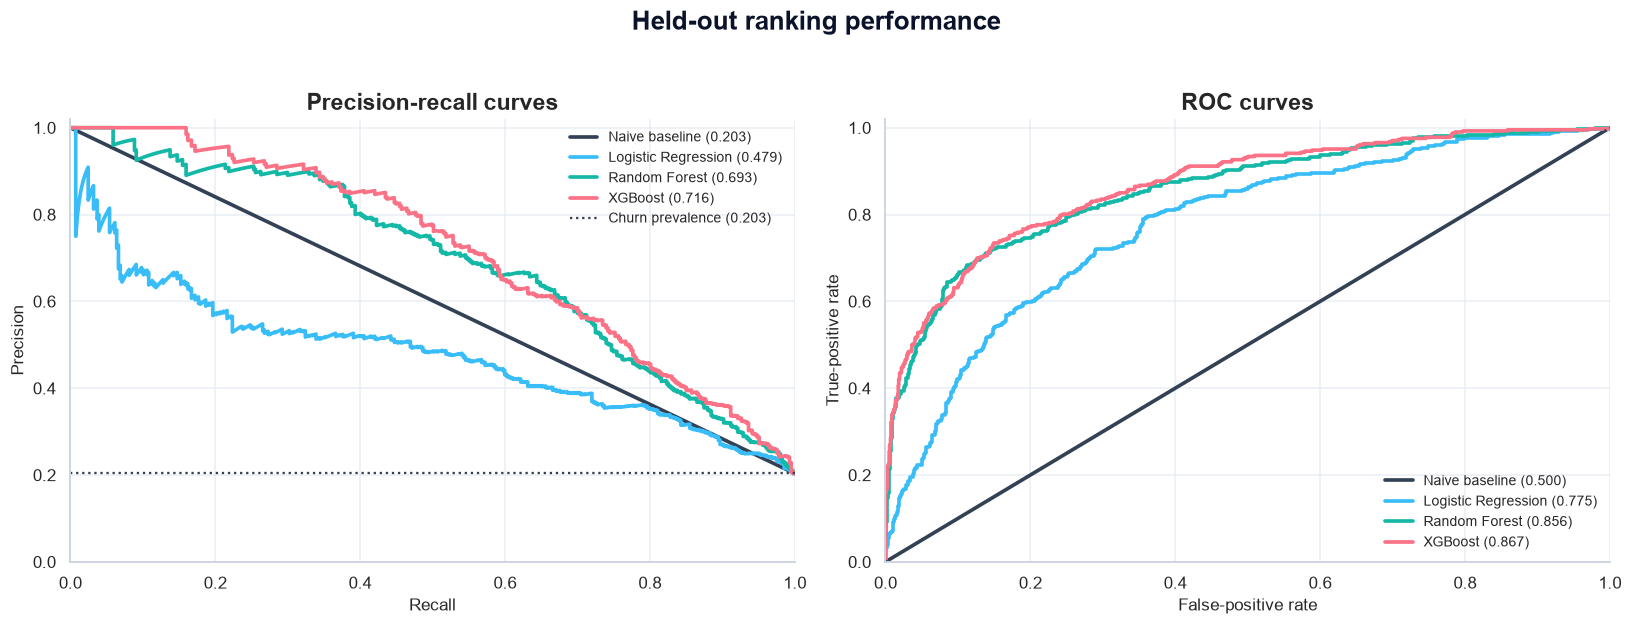

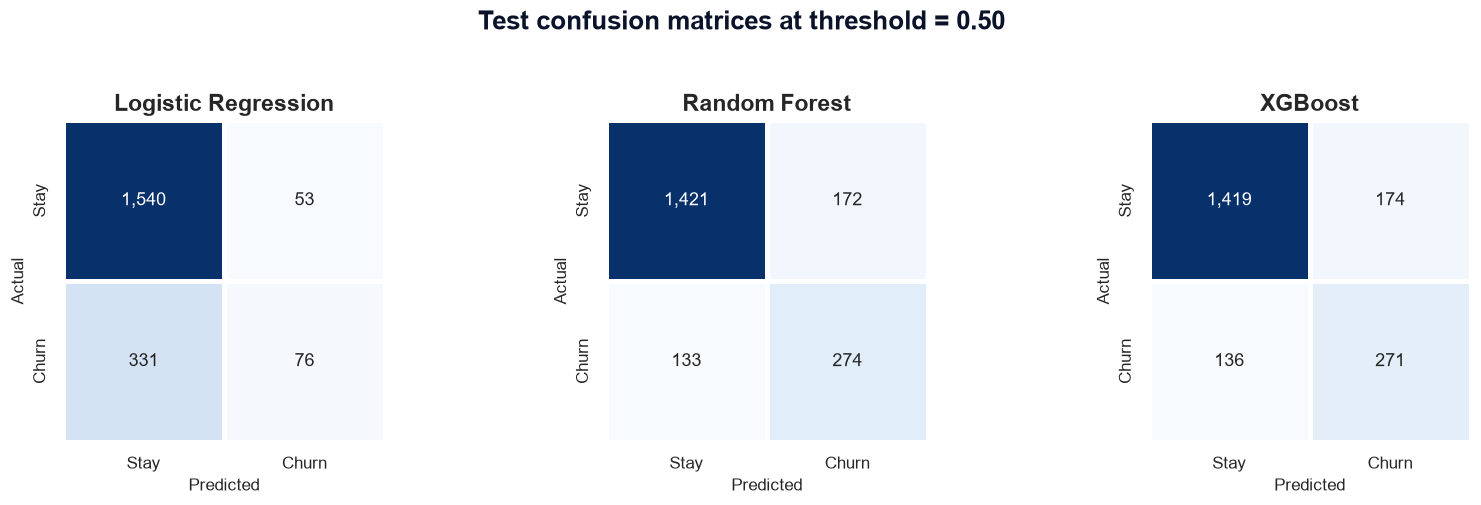

In [10]:
def metric_record(y_true, probabilities, threshold=0.50):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "PR-AUC": average_precision_score(y_true, probabilities),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "TN": confusion_matrix(y_true, predictions)[0, 0],
        "FP": confusion_matrix(y_true, predictions)[0, 1],
        "FN": confusion_matrix(y_true, predictions)[1, 0],
        "TP": confusion_matrix(y_true, predictions)[1, 1],
    }

baseline = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

evaluation_models = {"Naive baseline": baseline, **best_estimators}
test_probabilities = {}
test_predictions = {}
evaluation_rows = []

for model_name, estimator in evaluation_models.items():
    probabilities = estimator.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.50).astype(int)
    test_probabilities[model_name] = probabilities
    test_predictions[model_name] = predictions
    evaluation_rows.append({"Model": model_name, **metric_record(y_test, probabilities)})

model_evaluation = pd.DataFrame(evaluation_rows).set_index("Model")
required_metrics = ["Accuracy", "Precision", "Recall", "F1"]

model_evaluation_display = (
    model_evaluation[[*required_metrics, "PR-AUC", "ROC-AUC"]]
    .rename_axis("Model")
    .reset_index()
)
display(
    project_table(
        model_evaluation_display.style
        .hide(axis="index")
        .format({metric: "{:.3f}" for metric in [*required_metrics, "PR-AUC", "ROC-AUC"]})
        .background_gradient(subset=[*required_metrics, "PR-AUC", "ROC-AUC"], cmap="YlGnBu", axis=0),
        "Untouched test-set performance at threshold = 0.50",
    )
)

vertical_space(36)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for model_name, probabilities in test_probabilities.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilities)
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    axes[0].plot(recall_curve, precision_curve, linewidth=2.4,
                 color=MODEL_COLORS[model_name],
                 label=f"{model_name} ({average_precision_score(y_test, probabilities):.3f})")
    axes[1].plot(fpr, tpr, linewidth=2.4,
                 color=MODEL_COLORS[model_name],
                 label=f"{model_name} ({roc_auc_score(y_test, probabilities):.3f})")

axes[0].axhline(y_test.mean(), color=COLORS["slate"], linestyle=":", linewidth=1.5,
                label=f"Churn prevalence ({y_test.mean():.3f})")
axes[0].set(title="Precision-recall curves", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.02))
axes[1].plot([0, 1], [0, 1], color=COLORS["slate"], linestyle=":", linewidth=1.5)
axes[1].set(title="ROC curves", xlabel="False-positive rate", ylabel="True-positive rate", xlim=(0, 1), ylim=(0, 1.02))
for ax in axes:
    ax.legend(fontsize=9, loc="best")
fig.suptitle("Held-out ranking performance", fontsize=17, fontweight="bold", color=COLORS["navy"], y=1.03)
plt.tight_layout()
plt.show()

vertical_space(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, model_name in zip(axes, best_estimators):
    matrix = confusion_matrix(y_test, test_predictions[model_name])
    sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues", cbar=False, square=True,
                linewidths=2, linecolor="white", ax=ax,
                xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.suptitle("Test confusion matrices at threshold = 0.50", fontsize=17, fontweight="bold", color=COLORS["navy"], y=1.04)
plt.tight_layout()
plt.show()

**B6.** Verified held-out results at threshold 0.50:

| Model | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.808 | 0.589 | 0.187 | 0.284 |
| Random Forest | **0.848** | **0.614** | **0.673** | **0.642** |
| XGBoost | 0.845 | 0.609 | 0.666 | 0.636 |

The naive baseline is a warning: it achieves roughly 0.797 accuracy by predicting that everyone stays, but its churn recall and F1 are both zero.

## B7 - Which model performs better overall?

**XGBoost is selected as the risk-ranking model**, because selection was pre-defined using training-only PR-AUC rather than whichever model happened to win on the test set. It leads CV PR-AUC (0.699), test PR-AUC (0.716), and test ROC-AUC (0.867). The bank's recall priority is handled transparently by tuning the decision threshold on training-only predictions.

The conclusion is deliberately nuanced:

- **Random Forest** is best if the bank insists on threshold 0.50: it narrowly leads all four required test metrics - accuracy (84.8%), precision (61.4%), recall (67.3%), and F1 (64.2%).
- **XGBoost** is the better risk ranker across thresholds. At 0.50 it catches 271 of 407 test churners, three fewer than Random Forest, but its higher PR-AUC makes it more useful once the operating threshold is chosen for the bank's recall objective.
- **Logistic Regression** is interpretable but materially underfits nonlinear churn patterns; it misses 331 of 407 test churners at threshold 0.50.

The operational threshold is optimized later using training-only out-of-fold predictions.

# Part C - Feature Insights

## C8 - Feature importance

Permutation importance is calculated on the untouched test set using PR-AUC. Each raw feature is shuffled 15 times; a larger score decrease means the fitted XGBoost pipeline relied more on that feature for ranking churn risk. This method is preferable to impurity importance because it is evaluated out of sample and does not automatically favor high-cardinality variables.

Feature,Importance,Std
age,0.2605,0.0179
products_number,0.2562,0.0148
active_member,0.0949,0.0107
balance,0.0430,0.0046
country,0.0337,0.0053
gender,0.0142,0.0018
credit_score,0.0032,0.0020
tenure,0.0025,0.0013
credit_card,0.0007,0.0003
estimated_salary,0.0001,0.0031


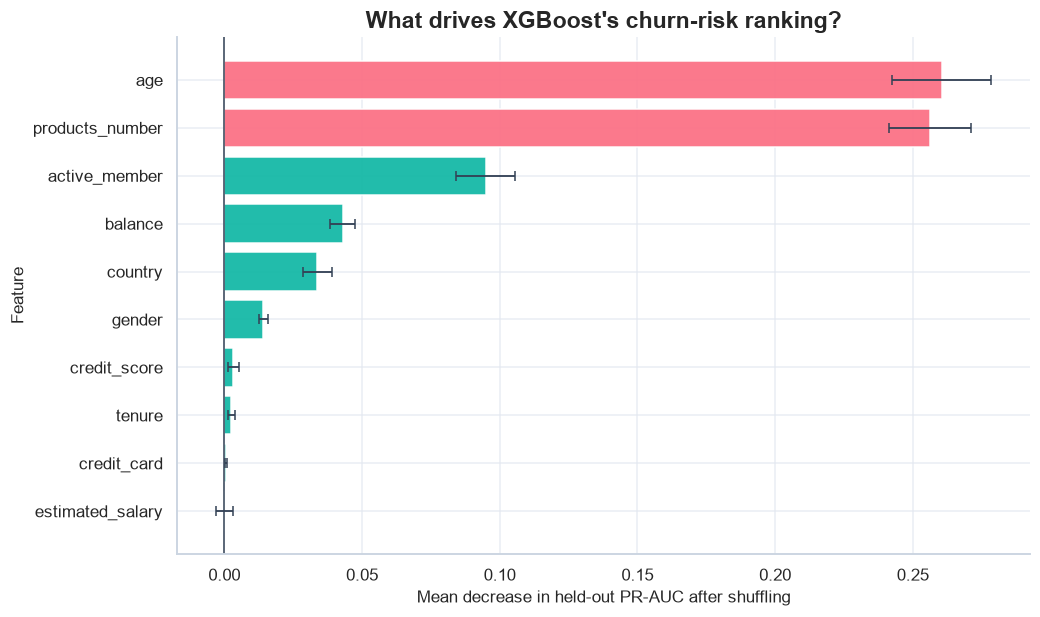

In [11]:
selected_model = best_estimators[selected_model_name]
permutation = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=SEARCH_JOBS,
)
importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": permutation.importances_mean,
        "Std": permutation.importances_std,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(
    project_table(
        importance_df.style
        .hide(axis="index")
        .format({"Importance": "{:.4f}", "Std": "{:.4f}"})
        .background_gradient(subset=["Importance"], cmap="YlGnBu"),
        "Permutation importance: mean decrease in test PR-AUC",
    )
)

vertical_space(34)
plot_importance = importance_df.sort_values("Importance")
feature_colors = [
    COLORS["coral"] if feature in importance_df.head(2)["Feature"].tolist() else COLORS["teal"]
    for feature in plot_importance["Feature"]
]
fig, ax = plt.subplots(figsize=(10, 6.1))
ax.barh(plot_importance["Feature"], plot_importance["Importance"],
        xerr=plot_importance["Std"], color=feature_colors, alpha=0.94,
        error_kw={"ecolor": COLORS["slate"], "capsize": 3, "elinewidth": 1.2})
ax.axvline(0, color=COLORS["slate"], linewidth=1)
ax.set_title(f"What drives {selected_model_name}'s churn-risk ranking?")
ax.set_xlabel("Mean decrease in held-out PR-AUC after shuffling")
ax.set_ylabel("Feature")
plt.show()

**C8.** The two dominant predictors are **`age`** (mean PR-AUC decrease about **0.261**) and **`products_number`** (about **0.256**). `active_member` (0.095), `balance` (0.043), and `country` (0.034) form a meaningful second tier. Credit score and estimated salary add almost no held-out ranking value after the other variables are known.

Importance measures predictive reliance, not direction or causality. The next analyses establish direction using observed segment churn rates.

## C9 - Churn across four age groups

The four business-readable ranges are **18-30**, **31-40**, **41-50**, and **51+** years. These fixed ranges are defined independently of the target. Wilson 95% confidence intervals are added to show sampling uncertainty.

age_group,Customers,Churners,Churn rate,95% CI low,95% CI high
18-30,"1,968",148,7.52%,6.44%,8.77%
31-40,"4,451",538,12.09%,11.16%,13.08%
41-50,"2,320",788,33.97%,32.07%,35.92%
51+,"1,261",563,44.65%,41.92%,47.40%


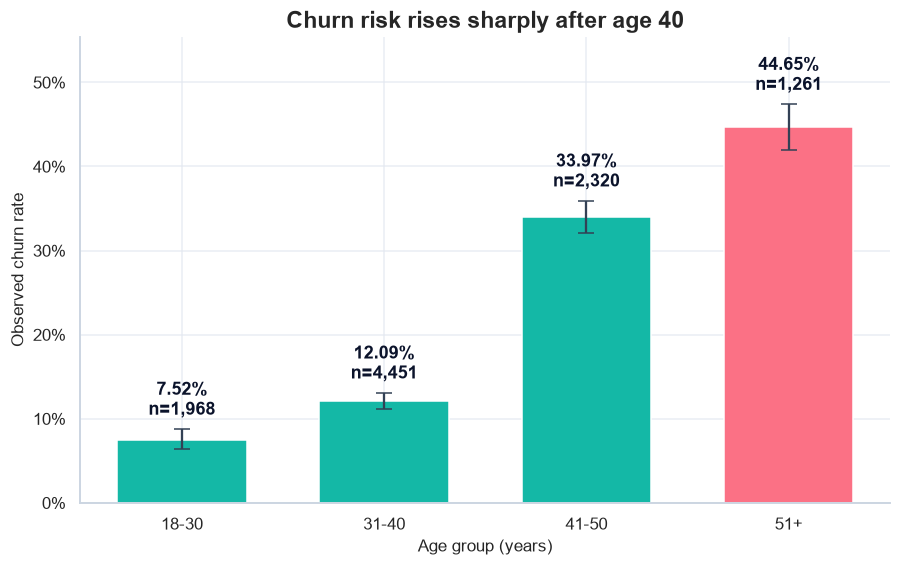

In [12]:
AGE_LABELS = ["18-30", "31-40", "41-50", "51+"]
age_group = pd.cut(
    df["age"],
    bins=[17, 30, 40, 50, np.inf],
    labels=AGE_LABELS,
    include_lowest=True,
)
age_summary = (
    df.assign(age_group=age_group)
    .groupby("age_group", observed=True)["churn"]
    .agg(Customers="size", Churners="sum", **{"Churn rate": "mean"})
    .reset_index()
)

z = 1.96
n = age_summary["Customers"].to_numpy()
p = age_summary["Churn rate"].to_numpy()
denominator = 1 + z**2 / n
center = (p + z**2 / (2 * n)) / denominator
half_width = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
age_summary["95% CI low"] = center - half_width
age_summary["95% CI high"] = center + half_width

display(
    project_table(
        age_summary.style
        .hide(axis="index")
        .format({
            "Customers": "{:,.0f}", "Churners": "{:,.0f}", "Churn rate": "{:.2%}",
            "95% CI low": "{:.2%}", "95% CI high": "{:.2%}",
        })
        .background_gradient(subset=["Churn rate"], cmap="YlOrRd"),
        "Observed churn by age group",
    )
)

vertical_space(34)
highest_age_group = age_summary.loc[age_summary["Churn rate"].idxmax(), "age_group"]
bar_colors = [COLORS["coral"] if group == highest_age_group else COLORS["teal"]
              for group in age_summary["age_group"]]
yerr = np.vstack([
    age_summary["Churn rate"] - age_summary["95% CI low"],
    age_summary["95% CI high"] - age_summary["Churn rate"],
])

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(age_summary["age_group"].astype(str), age_summary["Churn rate"],
              color=bar_colors, width=0.64, yerr=yerr, capsize=5,
              error_kw={"ecolor": COLORS["slate"], "elinewidth": 1.5})
ax.set_title("Churn risk rises sharply after age 40")
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Observed churn rate")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_ylim(0, age_summary["95% CI high"].max() + 0.08)
ax.bar_label(
    bars,
    labels=[f"{rate:.2%}{chr(10)}n={count:,}" for rate, count in zip(age_summary["Churn rate"], age_summary["Customers"])],
    padding=6,
    fontweight="bold",
    color=COLORS["navy"],
)
plt.show()

**C9.** Churn rates are **7.52%** for ages 18-30, **12.09%** for 31-40, **33.97%** for 41-50, and **44.65%** for 51+. Therefore, the **51+ group has the highest observed churn risk** (563 churners among 1,261 customers). The sharp rise after 40 is consistent with age being a leading model feature, but it remains an association; lifecycle needs, service experience, wealth migration, or unmeasured factors may explain it.

# Part D - Model Validation and Interpretation

## D10 - Most important metric when missed churners are costly

**Recall for the churn class is the most important threshold metric.** Recall is `TP / (TP + FN)` and directly measures the proportion of actual churners identified. A false negative is a customer who churns without being flagged for retention; maximizing accuracy can hide many such misses because almost 80% of customers stay.

Precision still matters for campaign capacity and cost, so the practical decision below selects a threshold that maximizes **F2**, which weights recall twice as strongly as precision. The threshold is selected exclusively from out-of-fold predictions on the training set.

Decision rule,Threshold,Accuracy,Precision,Recall,F1,FP,FN,TP
Default 0.50,0.500,0.845,0.609,0.666,0.636,174,136,271
Recall-first (training OOF F2),0.271,0.705,0.395,0.853,0.540,531,60,347


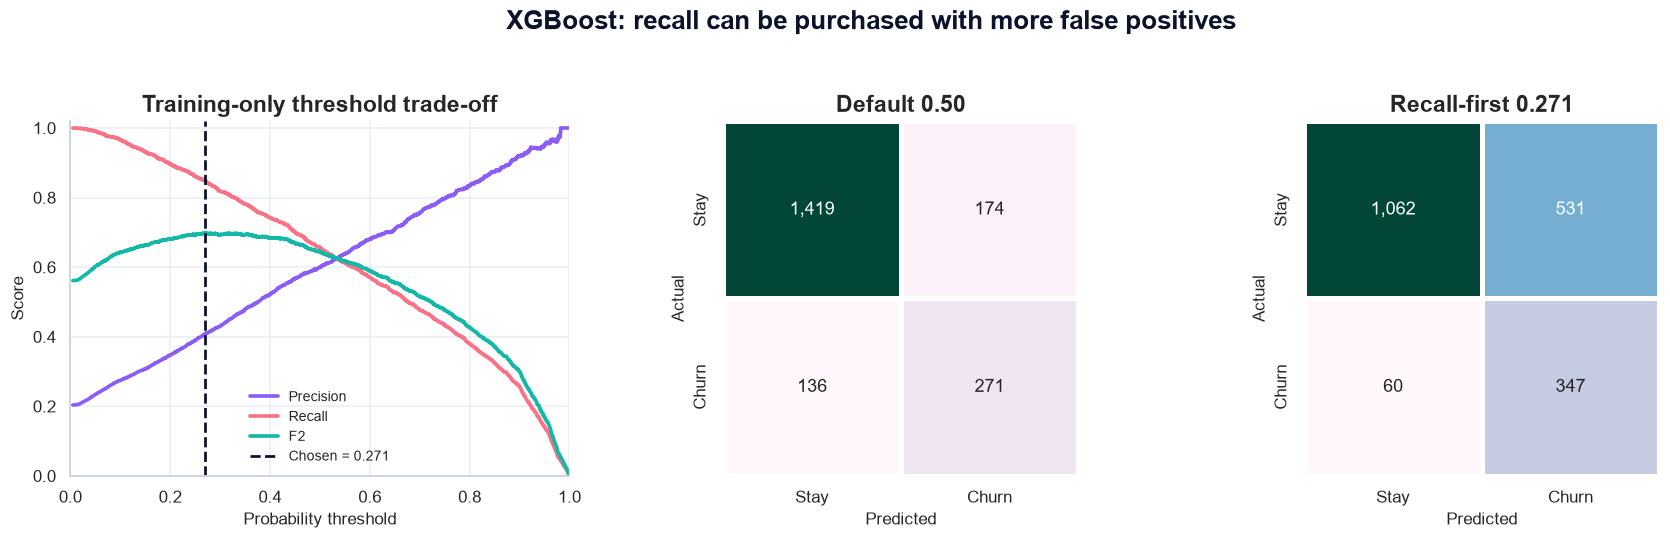

In [13]:
oof_probabilities = cross_val_predict(
    selected_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=SEARCH_JOBS,
)[:, 1]

oof_precision, oof_recall, thresholds = precision_recall_curve(y_train, oof_probabilities)
beta = 2
oof_f2 = (
    (1 + beta**2) * oof_precision[:-1] * oof_recall[:-1]
    / (beta**2 * oof_precision[:-1] + oof_recall[:-1] + 1e-12)
)
threshold_index = int(np.nanargmax(oof_f2))
operating_threshold = float(thresholds[threshold_index])

selected_test_probabilities = test_probabilities[selected_model_name]
default_record = metric_record(y_test, selected_test_probabilities, 0.50)
recall_record = metric_record(y_test, selected_test_probabilities, operating_threshold)

threshold_comparison = pd.DataFrame([
    {
        "Decision rule": "Default 0.50",
        "Threshold": 0.50,
        **{key: default_record[key] for key in ["Accuracy", "Precision", "Recall", "F1", "FP", "FN", "TP"]},
    },
    {
        "Decision rule": "Recall-first (training OOF F2)",
        "Threshold": operating_threshold,
        **{key: recall_record[key] for key in ["Accuracy", "Precision", "Recall", "F1", "FP", "FN", "TP"]},
    },
]).set_index("Decision rule")

display(
    project_table(
        threshold_comparison.reset_index().style
        .hide(axis="index")
        .format({
            "Threshold": "{:.3f}", "Accuracy": "{:.3f}", "Precision": "{:.3f}",
            "Recall": "{:.3f}", "F1": "{:.3f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}",
        })
        .background_gradient(subset=["Recall"], cmap="YlGn"),
        f"{selected_model_name} threshold comparison on untouched test data",
        "The recall-first threshold was selected using training out-of-fold predictions; all reported outcomes use the untouched test set.",
    )
)

vertical_space(36)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
axes[0].plot(thresholds, oof_precision[:-1], label="Precision", color=COLORS["purple"], linewidth=2.4)
axes[0].plot(thresholds, oof_recall[:-1], label="Recall", color=COLORS["coral"], linewidth=2.4)
axes[0].plot(thresholds, oof_f2, label="F2", color=COLORS["teal"], linewidth=2.4)
axes[0].axvline(operating_threshold, color=COLORS["navy"], linestyle="--", linewidth=1.8,
                label=f"Chosen = {operating_threshold:.3f}")
axes[0].set(title="Training-only threshold trade-off", xlabel="Probability threshold", ylabel="Score", xlim=(0, 1), ylim=(0, 1.02))
axes[0].legend(fontsize=9)

for ax, title, threshold_value in [
    (axes[1], "Default 0.50", 0.50),
    (axes[2], f"Recall-first {operating_threshold:.3f}", operating_threshold),
]:
    predictions = (selected_test_probabilities >= threshold_value).astype(int)
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(matrix, annot=True, fmt=",d", cmap="PuBuGn", cbar=False, square=True,
                linewidths=2, linecolor="white", ax=ax,
                xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")

fig.suptitle(f"{selected_model_name}: recall can be purchased with more false positives",
             fontsize=17, fontweight="bold", color=COLORS["navy"], y=1.04)
plt.tight_layout()
plt.show()

**D10.** Recall is the priority metric. The training-only F2 optimum selects an XGBoost threshold of approximately **0.271**. On the held-out test set, recall rises from **66.58% to 85.26%**: the bank catches **347 of 407** churners instead of 271, and false negatives fall from **136 to 60**. The cost is lower precision (**39.52%**) and 531 false-positive contacts. The final threshold should therefore be chosen from retention value, contact cost, and retention capacity, not from accuracy alone.

## D11 - Two key churn factors

The two strongest factors in held-out permutation importance are **number of products** and **age**. Segment rates below provide direction and sample sizes; the age direction was quantified in C9.

products_number,Customers,Churners,Churn rate
1,"5,084","1,409",27.71%
2,"4,590",348,7.58%
3,266,220,82.71%
4,60,60,100.00%


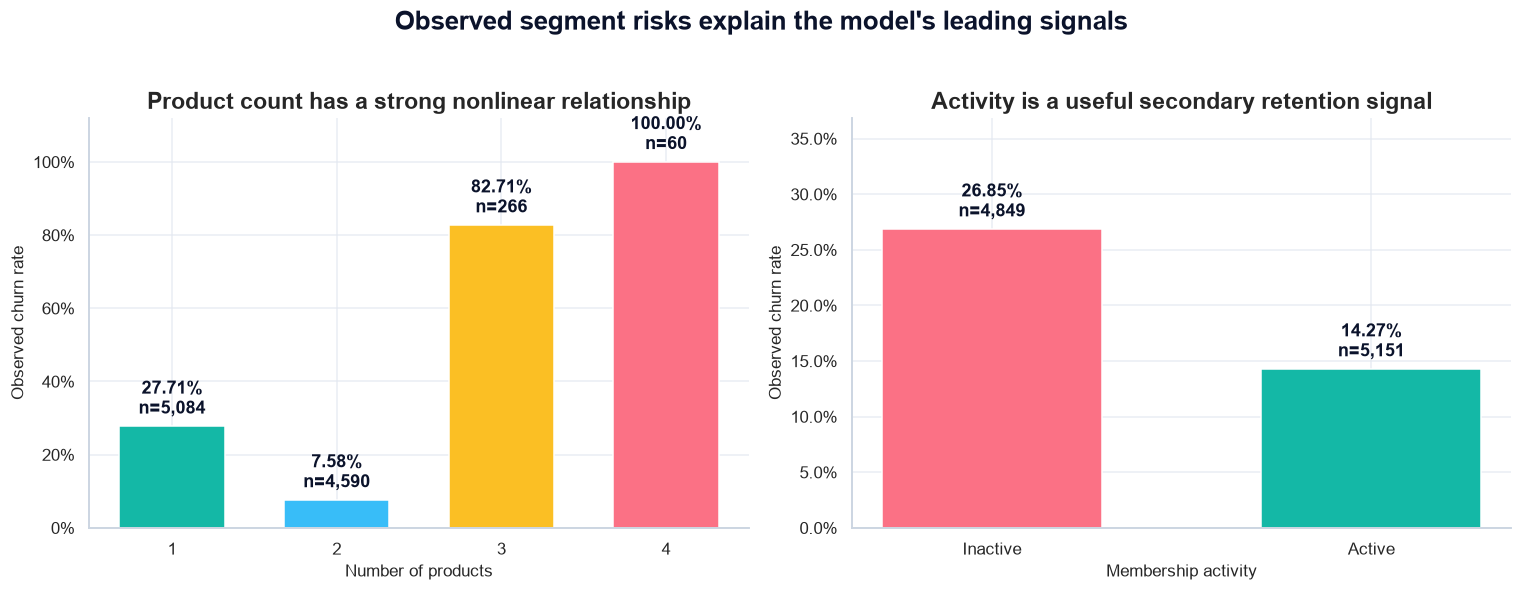

In [14]:
product_summary = (
    df.groupby("products_number")["churn"]
    .agg(Customers="size", Churners="sum", **{"Churn rate": "mean"})
    .reset_index()
)
activity_summary = (
    df.groupby("active_member")["churn"]
    .agg(Customers="size", Churners="sum", **{"Churn rate": "mean"})
    .reset_index()
)
activity_summary["Status"] = activity_summary["active_member"].map({0: "Inactive", 1: "Active"})

display(
    project_table(
        product_summary.style
        .hide(axis="index")
        .format({"Customers": "{:,.0f}", "Churners": "{:,.0f}", "Churn rate": "{:.2%}"})
        .background_gradient(subset=["Churn rate"], cmap="YlOrRd"),
        "Observed churn by number of bank products",
    )
)

vertical_space(36)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
product_colors = [COLORS["teal"], COLORS["cyan"], COLORS["amber"], COLORS["coral"]]
bars = axes[0].bar(product_summary["products_number"].astype(str), product_summary["Churn rate"],
                   color=product_colors, width=0.64)
axes[0].set(title="Product count has a strong nonlinear relationship", xlabel="Number of products", ylabel="Observed churn rate")
axes[0].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[0].set_ylim(0, 1.12)
axes[0].bar_label(
    bars,
    labels=[f"{rate:.2%}{chr(10)}n={count:,}" for rate, count in zip(product_summary["Churn rate"], product_summary["Customers"])],
    padding=5,
    fontweight="bold",
    color=COLORS["navy"],
)

bars = axes[1].bar(activity_summary["Status"], activity_summary["Churn rate"],
                   color=[COLORS["coral"], COLORS["teal"]], width=0.58)
axes[1].set(title="Activity is a useful secondary retention signal", xlabel="Membership activity", ylabel="Observed churn rate")
axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[1].set_ylim(0, activity_summary["Churn rate"].max() + 0.10)
axes[1].bar_label(
    bars,
    labels=[f"{rate:.2%}{chr(10)}n={count:,}" for rate, count in zip(activity_summary["Churn rate"], activity_summary["Customers"])],
    padding=5,
    fontweight="bold",
    color=COLORS["navy"],
)
fig.suptitle("Observed segment risks explain the model's leading signals", fontsize=17,
             fontweight="bold", color=COLORS["navy"], y=1.03)
plt.tight_layout()
plt.show()

**D11.**

1. **Products number:** customers with two products churn at only **7.58%**, compared with **27.71%** for one product, **82.71%** for three, and **100%** for four. The four-product result is based on only 60 customers and must not be generalized without more data; the pattern is strongly nonlinear, which helps explain why tree ensembles beat Logistic Regression.
2. **Age:** churn rises from **7.52%** at ages 18-30 to **44.65%** at 51+, with a major step-up after age 40.

A useful secondary signal is activity: inactive members churn at **26.85%**, versus **14.27%** for active members. None of these descriptive differences proves causality.

# Executive recommendation

**Deploy the tuned XGBoost model as a risk-ranking tool**, with the threshold chosen from campaign economics:

- Start with the training-derived **0.271 recall-first threshold** when the cost of missing churners is high.
- If contact capacity is fixed, rank customers by probability and target the highest-risk top *k* instead of treating 0.50 as a natural cutoff.
- Prioritize interventions for older customers, customers with one or three-plus products, inactive members, high-balance customers, and Germany-based customers - then validate offers with randomized experiments.
- Do not use age, gender, or country for adverse treatment without a legal, fairness, and policy review. These attributes can also be used for performance auditing rather than targeting.

## Limitations and next validation steps

- This is a single historical snapshot; no time variable is available, so random splitting may be more optimistic than a future-period validation.
- The model estimates probability of churn, not the probability that a retention action will prevent churn.
- Product-count segments 3 and 4 are small (`n=266` and `n=60`), so their extreme rates have wider uncertainty.
- Before production: validate on a later cohort, calibrate probabilities, quantify contact and offer costs, audit subgroup recall/false-positive rates, monitor drift, and run controlled uplift experiments.

In [15]:
completed_minutes = (time.perf_counter() - NOTEBOOK_STARTED) / 60
project_section_labels = ["A1", "A2", "A3", "B4", "B5", "B6", "B7", "C8", "C9", "D10", "D11"]
final_manifest = pd.DataFrame({
    "Item": [
        "Selected model", "Primary selection metric", "Operating threshold",
        "Test recall at operating threshold", "Random seed",
        "Project sections", "Total runtime",
    ],
    "Value": [
        selected_model_name,
        "5-fold CV average precision",
        f"{operating_threshold:.4f}",
        f"{recall_record['Recall']:.2%}",
        str(RANDOM_STATE),
        ", ".join(project_section_labels),
        f"{completed_minutes:.2f} minutes",
    ],
})

assert model_evaluation.loc[selected_model_name, "PR-AUC"] > y_test.mean()
assert recall_record["Recall"] >= default_record["Recall"]
assert len(importance_df) == X.shape[1]
assert len(age_summary) == 4
assert not model_evaluation.isna().any().any()

display(
    HTML(
        f'''
        <div style='padding:20px 24px;border-left:7px solid {COLORS['teal']};background:#ECFEFF;border-radius:12px;margin:14px 0'>
          <div style='font-size:20px;font-weight:800;color:{COLORS['navy']}'>Run completed successfully</div>
          <div style='margin-top:6px;color:{COLORS['slate']}'>All sections A1-D11 executed; integrity assertions, model checks, and interpretation tables passed.</div>
        </div>
        '''
    )
)
vertical_space(20)
display(
    project_table(
        final_manifest.style
        .hide(axis="index")
        .set_properties(**{"text-align": "left"}),
        "Final model and project summary",
    )
)

Item,Value
Selected model,XGBoost
Primary selection metric,5-fold CV average precision
Operating threshold,0.2706
Test recall at operating threshold,85.26%
Random seed,42
Project sections,"A1, A2, A3, B4, B5, B6, B7, C8, C9, D10, D11"
Total runtime,10.48 minutes
